In [7]:
# Import UsArrest dataset from an URL
import pandas as pd
# URL of the dataset
url = "https://raw.githubusercontent.com/maxmigue/machineLearning/refs/heads/main/Repo_Profe/S12-K-means/USArrests.csv"
# Read the dataset from the URL
df = pd.read_csv(url)
# Set the first column as the index
df.set_index('Unnamed: 0', inplace=True)
# Display the first few rows of the dataset
print(df.head())
# Display the shape of the dataset
print("\nShape of the dataset:", df.shape)
# Display the data types of the columns
print("\nData types of the columns:\n", df.dtypes)
# Display summary statistics of the dataset
print("\nSummary statistics of the dataset:\n", df.describe())
# Display the column names
print("\nColumn names:", df.columns.tolist())

            Murder  Assault  UrbanPop  Rape
Unnamed: 0                                 
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6

Shape of the dataset: (50, 4)

Data types of the columns:
 Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object

Summary statistics of the dataset:
          Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000

Column names: ['Murder', 'Assault', 'UrbanPop', 'R

In [10]:
# Normalize the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit and transform the data, including the first column
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
# Convert the normalized data back to a DataFrame
# Display the first few rows of the normalized dataset
print("\nNormalized dataset:\n", df_normalized.head())



Normalized dataset:
               Murder   Assault  UrbanPop      Rape
Unnamed: 0                                        
Alabama     1.255179  0.790787 -0.526195 -0.003451
Alaska      0.513019  1.118060 -1.224067  2.509424
Arizona     0.072361  1.493817  1.009122  1.053466
Arkansas    0.234708  0.233212 -1.084492 -0.186794
California  0.281093  1.275635  1.776781  2.088814


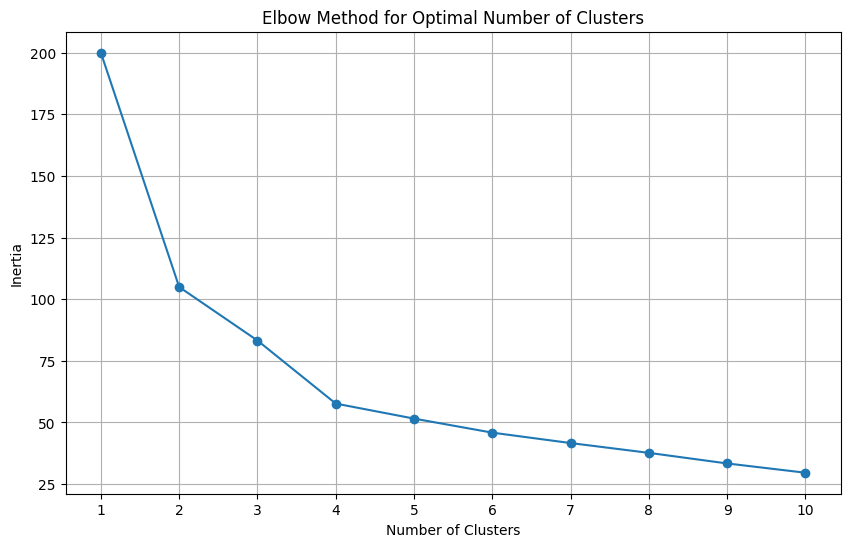

In [12]:
# Clustering using KMeans
from sklearn.cluster import KMeans
# Define the number of clusters using the Elbow method
import matplotlib.pyplot as plt
# Calculate the inertia for different numbers of clusters
inertia = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_normalized)
    inertia.append(kmeans.inertia_)
# Plot the inertia to visualize the Elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid()
plt.show()






In [19]:
# Based on the Elbow method, choose an optimal number of clusters
n_clusters = 4
# Create a KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# Fit the model to the normalized data
kmeans.fit(df_normalized)
# Add the cluster labels to the original DataFrame
df['Cluster'] = kmeans.labels_
# Display the first few rows of the DataFrame with cluster labels
print("\nDataFrame with cluster labels:\n", df.head())
# Number of samples in each cluster
print("\nNumber of samples in each cluster:\n", df['Cluster'].value_counts())


DataFrame with cluster labels:
             Murder  Assault  UrbanPop  Rape  Cluster
Unnamed: 0                                          
Alabama       13.2      236        58  21.2        1
Alaska        10.0      263        48  44.5        2
Arizona        8.1      294        80  31.0        2
Arkansas       8.8      190        50  19.5        1
California     9.0      276        91  40.6        2

Number of samples in each cluster:
 Cluster
3    17
0    13
2    12
1     8
Name: count, dtype: int64


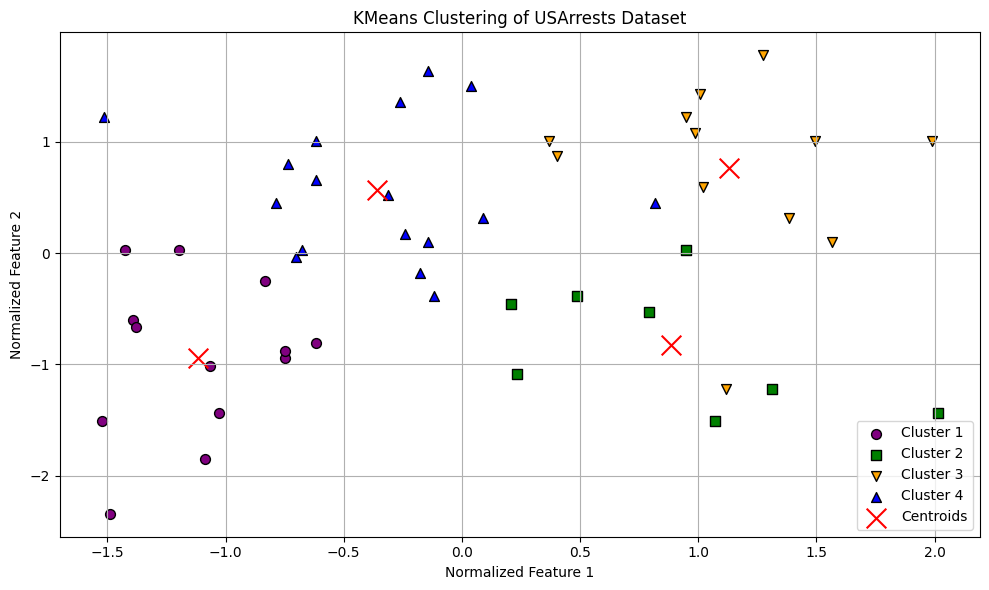

In [34]:
import matplotlib.pyplot as plt

# Define símbolos distintos para cada cluster
markers = ['o', 's', 'v', '^']  # Puedes ajustar según el número de clusters
colors = ['purple', 'green', 'orange', 'blue']  # También puedes usar cmap

plt.figure(figsize=(10, 6))

# Graficar cada cluster con su símbolo y color
for cluster_label in sorted(df['Cluster'].unique()):
    cluster_points = df_normalized[df['Cluster'] == cluster_label]
    plt.scatter(
        cluster_points.iloc[:, 1],
        cluster_points.iloc[:, 2],
        s=50,
        c=colors[cluster_label],
        marker=markers[cluster_label],
        edgecolor='black',
        label=f'Cluster {cluster_label + 1}'
    )

# Mostrar centroides (asumiendo que están en el mismo espacio de las dos primeras features)
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 1], centroids[:, 2],
    c='red', marker='x', s=200, label='Centroids'
)

# Etiquetas y leyenda
plt.title('KMeans Clustering of USArrests Dataset')
plt.xlabel('Normalized Feature 1')
plt.ylabel('Normalized Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Scatter plot matrix by cluster


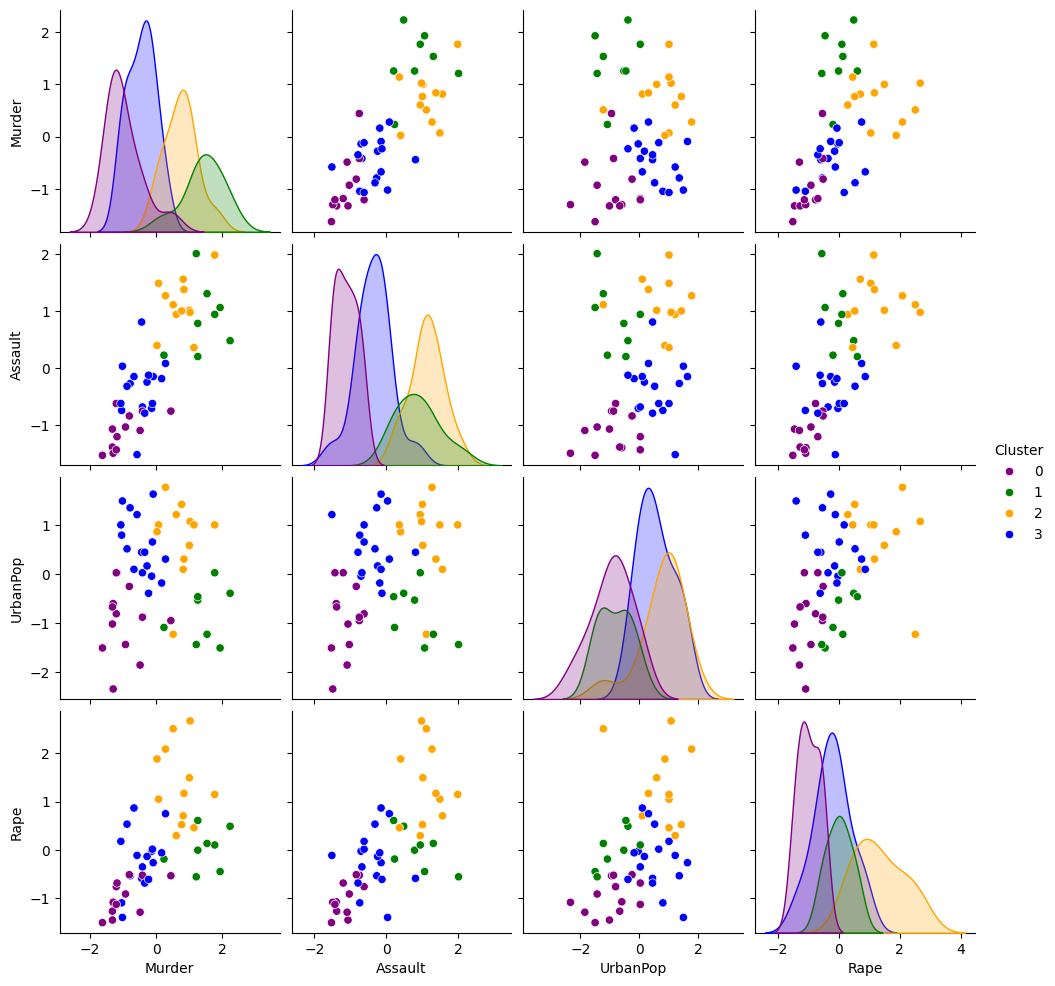

In [35]:
import seaborn as sns

# Add the cluster labels as a column to the normalized DataFrame for plotting
df_normalized['Cluster'] = df['Cluster']

# Create a scatter plot matrix with hue based on the cluster
sns.pairplot(df_normalized, hue='Cluster', palette=colors, diag_kind='kde')

# Display the plot
plt.show()